# URDF
URDF（Unified Robot Description Format）统一机器人描述格式，URDF使用XML格式描述机器人文件。  

XML是 被设计用来传输和存储数据的可扩展标记语言，注意语言本身是没有含义的，只是规定了其数据格式

比如：

```xml
<robot name="阿童木">
<link name="大手臂">具体的描述</link>
<joint name="胳膊肘">具体的描述</joint>
<link name="小手臂">具体的描述</link>
</robot>
```

XML格式在线校验工具:https://tool.oschina.net/codeformat/xml

XML格式注释： 标签: ``robot link``

robot标签的属性name: ``<robot name="fishbot"></robot>``

robot标签的子标签link: ``<robot name="fishbot"><link name="base_link"></link>link></robot>``

## URDF的组成
一般情况下，URDF由``声明信息``和``两种关键组件``共同组成

### 声明信息
声明信息包含两部分，第一部分是xml的声明信息，放在第一行 第二部分是机器人的声明，通过robot标签就可以声明一个机器人模型
```xml
<?xml version="1.0"?>
<robot name="fishbot">
  <link name="base_link">
    <visual>
      <geometry>
        <cylinder length="0.18" radius="0.06"/>
      </geometry>
    </visual>
  </link>
</robot>
```

### 两种关键组件(Joint&Link)
对于一个机器人，我们把左轮，右轮、支撑轮子，IMU和雷达部件等称为机器人的Link

而Link和Link之间的连接部分称之为Joint关节

接着我们给每个link和joint取个名字

接着我们分别对link和joint进行详细的介绍

## Link
通过link标签即可声明一个link,属性name指定部件名字
```xml
  <link name="base_link">

  </link>
```
通过visual子标签就可以声明出来机器人的visual形状
```xml
  <!-- base link -->
  <link name="base_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
    </visual>
  </link>
```

### link标签
```
visual 显示形状
  <geometry> (几何形状)
    <box> 长方体
      标签属性: size-长宽高
      举例：<box size="1 1 1" />
    <cylinder> 圆柱体
      标签属性:radius-半径 length-高度
      举例：<cylinder radius="1" length="0.5"/>
    sphere 球体
      属性：radius -半径
      举例：<sphere radius="0.015"/>
    mesh 第三方导出的模型文件
      属性：filename
      举例: <mesh filename="package://robot_description/meshes/base_link.DAE"/>
  origin (可选：默认在物体几何中心)
    属性 xyz默认为零矢量 rpy弧度表示的翻滚、俯仰、偏航
    举例：<origin xyz="0 0 0" rpy="0 0 0" />
  material 材质
    属性 name 名字
      color
        属性 rgba a代表透明度
        举例：<material name="white"><color rgba="1.0 1.0 1.0 0.5" /> </material>
collision 碰撞属性，仿真章节中讲解
inertial 惯性参数 质量等，仿真章节中讲解
```

## Joint
joint为机器人关节，机器人关节用于连接两个机器人部件，主要写明父子关系  

- 父子之间的连接类型，包括是否固定的，可以旋转的等
- 父部件名字
- 子部件名字
- 父子之间相对位置
- 父子之间的旋转轴，绕哪个轴转

比如我们再建立一个雷达部件laser_link，然后将laser_link固定到base_link
```xml
<?xml version="1.0"?>
<robot name="fishbot">
    
  <!-- base link -->
  <link name="base_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
    </visual>
  </link>
    
  <!-- laser link -->
  <link name="laser_link">
      <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.02" radius="0.02"/>
      </geometry>
      <material name="black">
          <color rgba="0.0 0.0 0.0 0.5" /> 
      </material>
    </visual>
  </link>
    
  <!-- laser joint -->
    <joint name="laser_joint" type="fixed">
        <parent link="base_link" />
        <child link="laser_link" />
        <origin xyz="0 0 0.075" />
    </joint>

</robot>
```

### Joint标签
**属性**
- name 关节的名称
- type 关节的类型
  - revolute: 旋转关节，绕单轴旋转,角度有上下限,比如舵机0-180
  - continuous: 旋转关节，可以绕单轴无限旋转,比如自行车的前后轮
  - fixed: 固定关节，不允许运动的特殊关节
  - prismatic: 滑动关节，沿某一轴线移动的关节，有位置极限
  - planer: 平面关节，允许在xyz，rxryrz六个方向运动
  - floating: 浮动关节，允许进行平移、旋转运动

**子标签**
- parent 父link名称
  - ``<parent link="base_link" />``
- child子link名称
  - ``<child link="laser_link" />``
- origin 父子之间的关系xyz rpy
  - ``<origin xyz="0 0 0.014" />``
- axis 围绕旋转的关节轴
  - ``<axis xyz="0 0 1" />``

# RVIZ2 可视化 URDF 模型
URDF可视化的步骤如下：
1. 建立机器人描述功能包
2. 建立urdf文件夹，编写urdf文件
3. 建立launch文件夹，编写launch文件
4. 修改setup.py配置，编译测试

## 建立功能包
先创建一个chapt8_ws工作空间，然后建立功能包，包的类型选ament_python
```
mkdir -p chapt8/chapt8_ws/src
cd chapt8/chapt8_ws/src
ros2 pkg create fishbot_description --build-type ament_python
```

## 创建urdf文件夹编写urdf文件
创建URDF文件夹，创建urdf文件
```
mkdir fishbot_description/urdf
touch fishbot_description/urdf/fishbot_base.urdf
```
完成后src下的目录结构：
```
├── fishbot_description
│   ├── __init__.py
├── package.xml
├── setup.cfg
├── setup.py
└── urdf
    └── fishbot_base.urdf
```
编辑fishbot_base.urdf
```xml
<?xml version="1.0"?>
<robot name="fishbot">
    
  <!-- base link -->
  <link name="base_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
    </visual>
  </link>
    
  <!-- laser link -->
  <link name="laser_link">
      <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.02" radius="0.02"/>
      </geometry>
      <material name="black">
          <color rgba="0.0 0.0 0.0 0.8" /> 
      </material>
    </visual>
  </link>
    
  <!-- laser joint -->
    <joint name="laser_joint" type="fixed">
        <parent link="base_link" />
        <child link="laser_link" />
        <origin xyz="0 0 0.075" />
    </joint>

</robot>
```

## 创建launch文件夹编写launch文件
在目录src/fishbot_description下创建launch文件夹并在其下新建display_rviz2.launch.py文件
```
mkdir launch
touch launch/display_rviz2.launch.py
```
完成后的目录结构：
```
├── fishbot_description
│   ├── __init__.py
├── launch
│   └── display_rviz2.launch.py
├── package.xml
├── setup.cfg
├── setup.py
└── urdf
    └── fishbot_base.urdf
```
.launch.py文件
```py
import os
from launch import LaunchDescription
from launch.substitutions import LaunchConfiguration
from launch_ros.actions import Node
from launch_ros.substitutions import FindPackageShare


def generate_launch_description():
    package_name = 'fishbot_description'
    urdf_name = "fishbot_base.urdf"

    ld = LaunchDescription()
    pkg_share = FindPackageShare(package=package_name).find(package_name) 
    urdf_model_path = os.path.join(pkg_share, f'urdf/{urdf_name}')

    robot_state_publisher_node = Node(
        package='robot_state_publisher',
        executable='robot_state_publisher',
        arguments=[urdf_model_path]
        )

    joint_state_publisher_node = Node(
        package='joint_state_publisher_gui',
        executable='joint_state_publisher_gui',
        name='joint_state_publisher_gui',
        arguments=[urdf_model_path]
        )

    rviz2_node = Node(
        package='rviz2',
        executable='rviz2',
        name='rviz2',
        output='screen',
        )

    ld.add_action(robot_state_publisher_node)
    ld.add_action(joint_state_publisher_node)
    ld.add_action(rviz2_node)

    return ld
```

想要可视化模型需要三个节点参与

joint_state_publisher_gui 负责发布机器人关节数据信息，通过joint_states话题发布

robot_state_publisher_node负责发布机器人模型信息robot_description，并将joint_states数据转换tf信息发布

rviz2_node负责显示机器人的信息

``joint_state_publisher`` --> ``joint_states`` --> ``robot_state_publisher`` --> ``robot_description`` --> ``rviz2``

这里我们用到了joint_state_publisher_gui和robot_state_publisher两个包，如果你的系统没有安装这两个包，可以手动安装:
```
sudo apt install ros-$ROS_DISTRO-joint-state-publisher-gui ros-$ROS_DISTRO-robot-state-publisher
```

## 修改setup.py编译测试
```py
from setuptools import setup
from glob import glob
import os

package_name = 'fishbot_description'

setup(
    name=package_name,
    version='0.0.0',
    packages=[package_name],
    data_files=[
        ('share/ament_index/resource_index/packages',
            ['resource/' + package_name]),
        ('share/' + package_name, ['package.xml']),
        (os.path.join('share', package_name, 'launch'), glob('launch/*.launch.py')),
        (os.path.join('share', package_name, 'urdf'), glob('urdf/**')),
    ],
    install_requires=['setuptools'],
    zip_safe=True,
    maintainer='root',
    maintainer_email='root@todo.todo',
    description='TODO: Package description',
    license='TODO: License declaration',
    tests_require=['pytest'],
    entry_points={
        'console_scripts': [
        ],
    },
)
```
编译测试
```
colcon build

source install/setup.bash
ros2 launch fishbot_description display_rviz2.launch.py
```
添加robotmodel模块，分别选择link名称如下，即可看到机器人的模型显示  
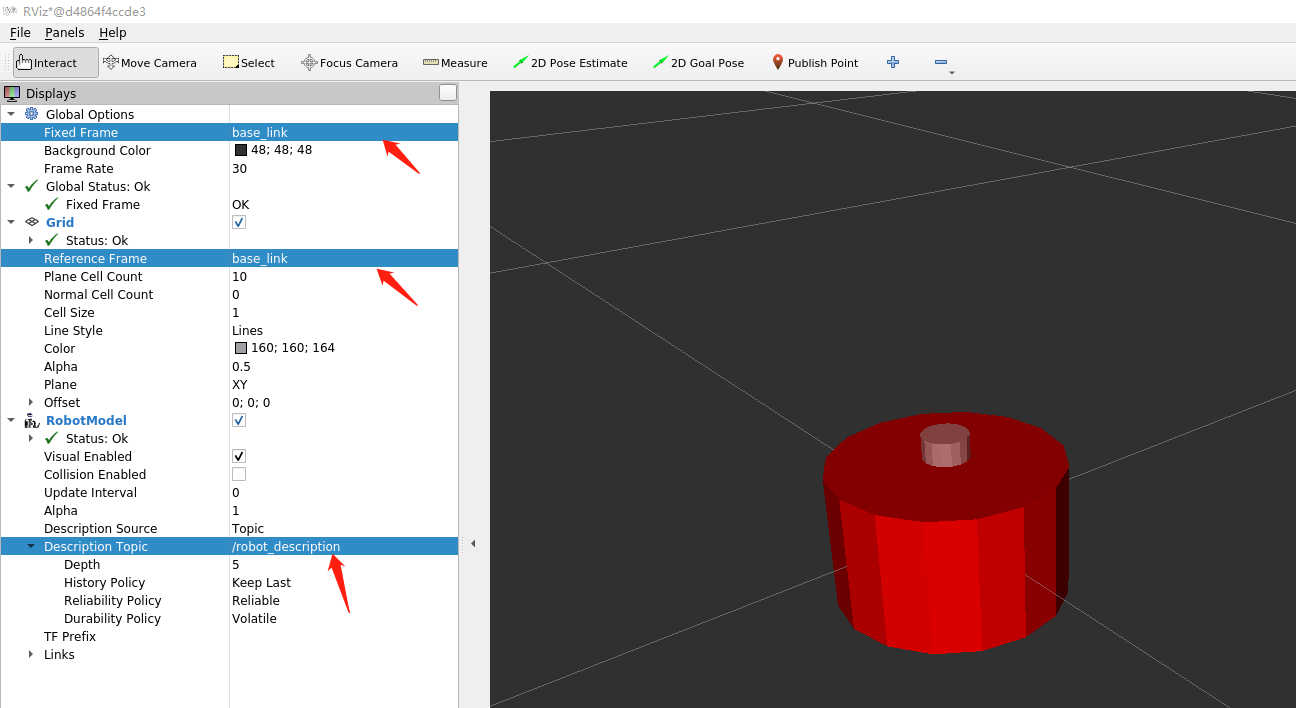  
此时看看节点关系图  
打开rqt，在 rqt 工具的菜单栏中，选择Plugins（插件）> Introspection（内省）> Node Graph  
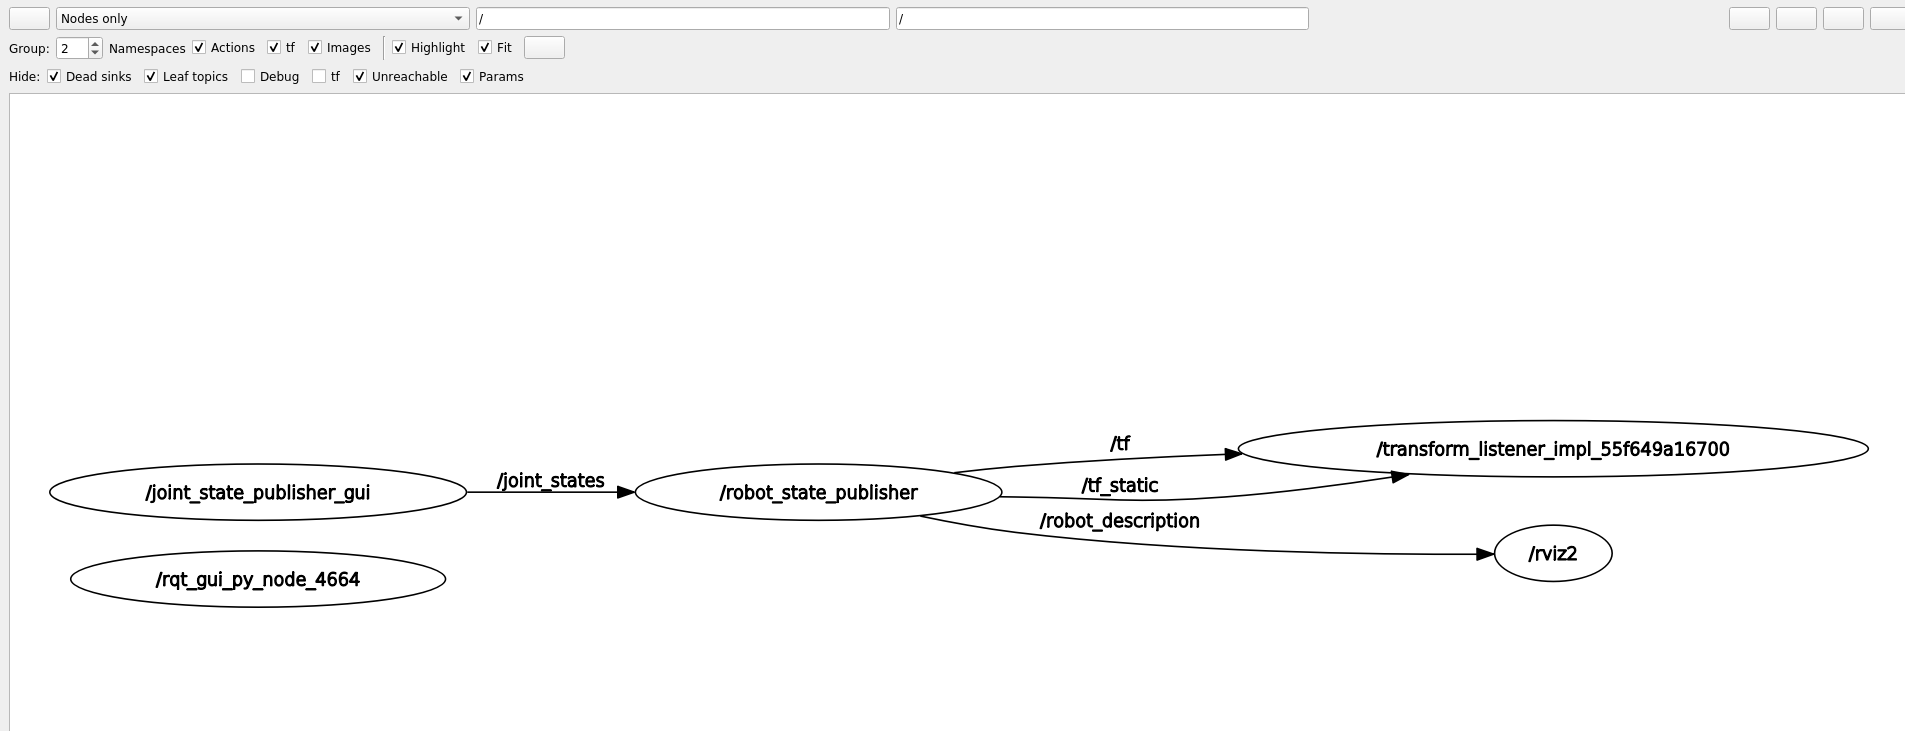  
然后打开TF模块，看一下机器人的坐标系关系  
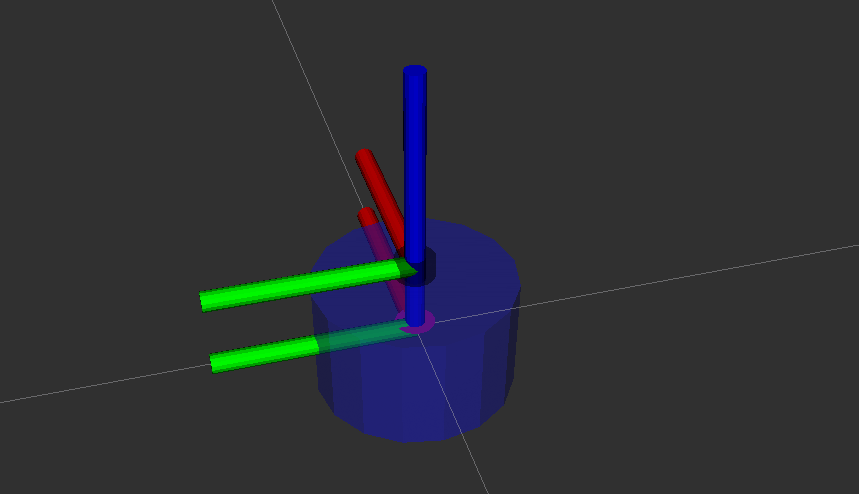

练习1：尝试将修改机器人身体颜色为蓝色，透明度为50%(0.1 0.1 1.0 0.5)

练习2：尝试在URDF中添加imu_link并使用imu_joint将其固定在车体的中心上方2cm，imu采用的几何形状为box,长宽高各是2cm

透明度修改只需要在base_link中添加material
```xml
<link name="base_link">
    <visual>
        <origin xyz="0 0 0.0" rpy="0 0 0"/>
    <geometry>
        <cylinder length="0.12" radius="0.10"/>
    </geometry>
    <material name="blue">
        <color rgba="0.1 0.1 1.0 0.5" /> 
    </material>
    </visual>
</link>
```

添加imu
```xml
  <!-- imu link -->
  <link name="imu_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
            <box size="0.02 0.02 0.02"/>
      </geometry>
    </visual>
  </link>

  <!-- imu joint -->
  <joint name="imu_joint" type="fixed">
      <parent link="base_link" />
      <child link="imu_link" />
      <origin xyz="0 0 0.02" />
  </joint>
```

# 创建一个两轮差速模型
接下来添加如下部件和关节：
- IMU传感器部件与关节
- 左轮子部件与关节
- 右轮子部件与关节
- 支撑轮子部件与关节

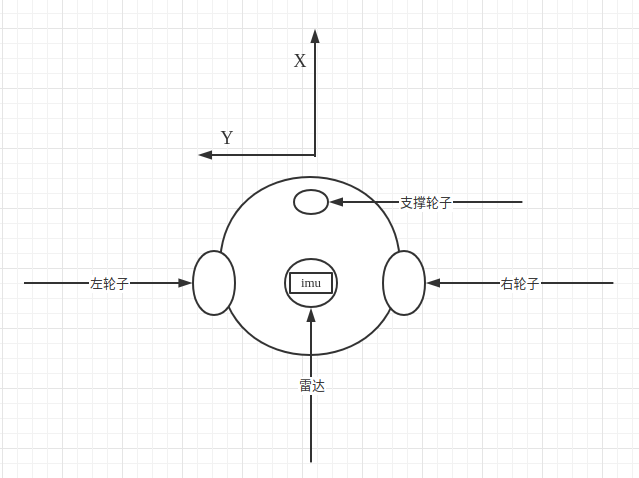

## 添加imu
见上节练习

## 添加右轮
关节名称为right_wheel_link，轮子的宽为4cm,直径为6.4cm,几何形状是个圆柱体  

需要注意的是,圆柱默认的朝向是向上的

我们可通过origin的rpy改变轮子的旋转角度，让其绕x轴旋转pi/2

颜色换黑色，可以得到下面的配置：
```xml
  <link name="right_wheel_link">
      <visual>
        <origin xyz="0 0 0" rpy="1.57079 0 0"/>
        <geometry>
          <cylinder length="0.04" radius="0.032"/>
        </geometry>
          <material name="black">
            <color rgba="0.0 0.0 0.0 0.5" /> 
          </material>
      </visual>
  </link>
```
我们把右轮子的中心固定在机器人右后方

需要注意的是origin和axis值的设置

先看origin

因为base_link的高度是0.12,我们

z表示child相对parent的z轴上的关系，想将轮子固定在机器人的下表面,所以origin的z向下偏移0.12/2=0.06m(向下符号为负)

y表示child相对parent的y轴上的关系，base_link的半径是0.10,所以我们让轮子的y轴向负方向偏移0.10m(向左符号为负)

x表示child相对parent的x轴上的关系，向后偏移则是x轴向后进行偏移，我们用个差不多的值0.02m(向后符号为负)

再看axis

轮子是会转动的，那应该按照哪个轴转动呢？从上图可以看出是绕着y轴的逆时针方向，所以axis的设置为：``<axis xyz="0 1 0" />``

```xml
  <joint name="right_wheel_joint" type="continuous">
      <parent link="base_link" />
      <child link="right_wheel_link" />
      <origin xyz="-0.02 -0.10 -0.06" />
      <axis xyz="0 1 0" />
  </joint>
```

## 添加左轮
左轮就是右轮的映射，不再赘述
```xml
  <link name="left_wheel_link">
      <visual>
        <origin xyz="0 0 0" rpy="1.57079 0 0"/>
        <geometry>
          <cylinder length="0.04" radius="0.032"/>
        </geometry>
          <material name="black">
            <color rgba="0.0 0.0 0.0 0.5" /> 
          </material>
      </visual>
  </link>
    
  <joint name="left_wheel_joint" type="continuous">
      <parent link="base_link" />
      <child link="left_wheel_link" />
      <origin xyz="-0.02 0.10 -0.06" />
      <axis xyz="0 1 0" />
  </joint>
```

## 添加支撑轮
支撑轮子固定在机器人的前方，用个球体，半径用0.016m，小球的直径为0.032m与左右轮子半径相同，然后向下偏移0.016+0.06=0.076m,向下值为负，同时把支撑论向前移动一些，选个0.06m
```xml
<link name="caster_link">
    <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry>
          <sphere radius="0.016"/>
      </geometry>
        <material name="black">
          <color rgba="0.0 0.0 0.0 0.5" /> 
        </material>
    </visual>
  </link>
    
  <joint name="caster_joint" type="fixed">
      <parent link="base_link" />
      <child link="caster_link" />
      <origin xyz="0.06 0.0 -0.076" />
  </joint>
```

## 最终URDF文件
```xml
<?xml version="1.0"?>
<robot name="fishbot">
    
  <!-- base link -->
  <link name="base_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
      <material name="blue">
          <color rgba="0.1 0.1 1.0 0.5" /> 
      </material>
    </visual>
  </link>
    
  <!-- laser link -->
  <link name="laser_link">
      <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.02" radius="0.02"/>
      </geometry>
      <material name="black">
          <color rgba="0.0 0.0 0.0 0.5" /> 
      </material>
    </visual>
  </link>
    
  <!-- laser joint -->
  <joint name="laser_joint" type="fixed">
      <parent link="base_link" />
      <child link="laser_link" />
      <origin xyz="0 0 0.075" />
  </joint>

  <link name="imu_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
            <box size="0.02 0.02 0.02"/>
      </geometry>
    </visual>
  </link>

  <!-- imu joint -->
  <joint name="imu_joint" type="fixed">
      <parent link="base_link" />
      <child link="imu_link" />
      <origin xyz="0 0 0.02" />
  </joint>


  <link name="left_wheel_link">
      <visual>
        <origin xyz="0 0 0" rpy="1.57079 0 0"/>
        <geometry>
          <cylinder length="0.04" radius="0.032"/>
        </geometry>
          <material name="black">
            <color rgba="0.0 0.0 0.0 0.5" /> 
          </material>
      </visual>
  </link>
    
  <joint name="left_wheel_joint" type="continuous">
      <parent link="base_link" />
      <child link="left_wheel_link" />
      <origin xyz="-0.02 0.10 -0.06" />
      <axis xyz="0 1 0" />
  </joint>

  <link name="right_wheel_link">
      <visual>
        <origin xyz="0 0 0" rpy="1.57079 0 0"/>
        <geometry>
          <cylinder length="0.04" radius="0.032"/>
        </geometry>
          <material name="black">
            <color rgba="0.0 0.0 0.0 0.5" /> 
          </material>
      </visual>
  </link>
    
  <joint name="right_wheel_joint" type="continuous">
      <parent link="base_link" />
      <child link="right_wheel_link" />
      <origin xyz="-0.02 -0.10 -0.06" />
      <axis xyz="0 1 0" />
  </joint>

  <link name="caster_link">
    <visual>
      <origin xyz="0 0 0" rpy="1.57079 0 0"/>
      <geometry>
          <sphere radius="0.016"/>
      </geometry>
        <material name="black">
          <color rgba="0.0 0.0 0.0 0.5" /> 
        </material>
    </visual>
  </link>
    
  <joint name="caster_joint" type="fixed">
      <parent link="base_link" />
      <child link="caster_link" />
      <origin xyz="0.06 0.0 -0.076" />
      <axis xyz="0 1 0" />
  </joint>



</robot>
```

## 编译测试
```
colcon build
source install/setup.bash
ros2 launch fishbot_description display_rviz2.launch.py
```
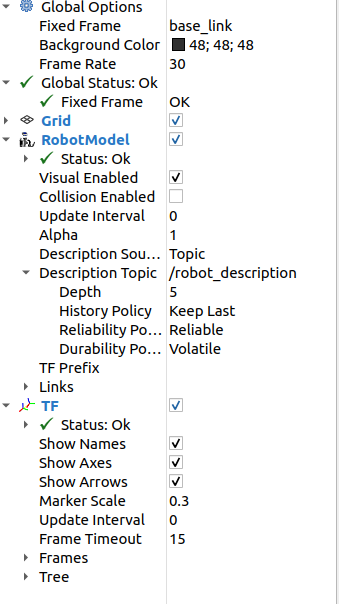  
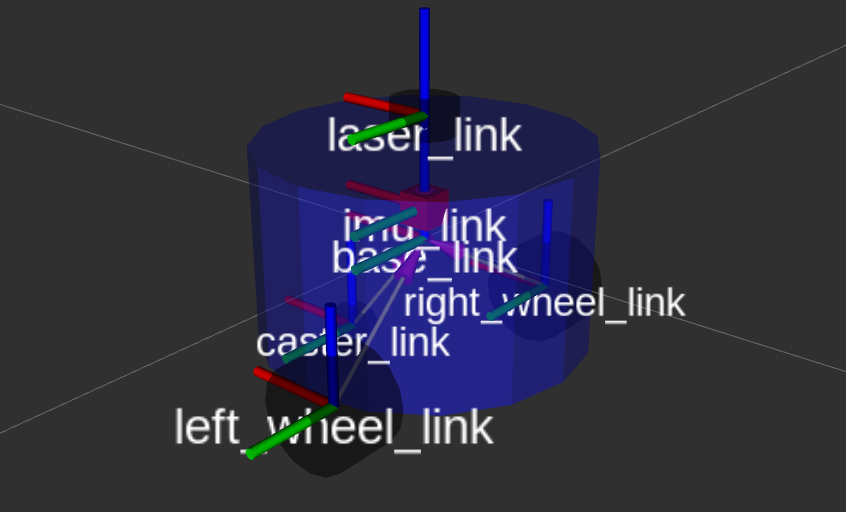  
jointstate多出两个滑动条  
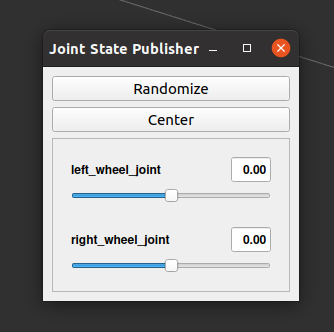  
打印joint_states话题
```
ros2 topic echo /joint_states
```
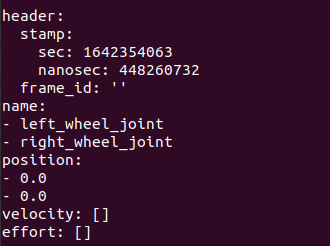  

在JointStatePublisher中,拖动滑动条,观察
- rviz2中tf的变换
- joint_states中的值的变换

可以看到随着进度条拖动,话题中的值和rviz2中机器人关节在同步的旋转,joint_states话题也可以手动发送,下一节我们通过手动发送joint_states来控制机器人轮子转动

## 如何让车轮着地
虽然显示出了机器人模型，但有一个问题，那就是在RVIZ中的机器人轮子是在地面之下的。

原因在于我们fixed-frame选择的是base_link,base_link的位置本来就在left_wheel_link和right_wheel_link只上，那该怎么办呢？

其实很简单，我们增加一个虚拟link和关节，这个关节与base_link相连，位置位于base_link向下刚好到车轮下表面的位置。

来，让我们**给base_link添加一个父link-base_footprint**，新增的URDF代码如下：
```xml
  <!-- Robot Footprint -->
  <link name="base_footprint"/>

  <joint name="base_joint" type="fixed">
    <parent link="base_footprint"/>
    <child link="base_link"/>
    <origin xyz="0.0 0.0 0.076" rpy="0 0 0"/>
  </joint>

```
因为是虚拟关节，我们不用对这个link的形状进行描述，joint的origin设置为xyz="0.0 0.0 0.076"表示关节base_footprint向上0.076就是base_link

保存编译再次运行测试，此时车轮就在地面上了

# 通过JiontStates控制RVIZ2关节
我们需要自己编写节点,取代joint_state_publisher发送关节位姿给robot_state_pubsher，robot_state_publisher发送tf控制机器人的关节转动。

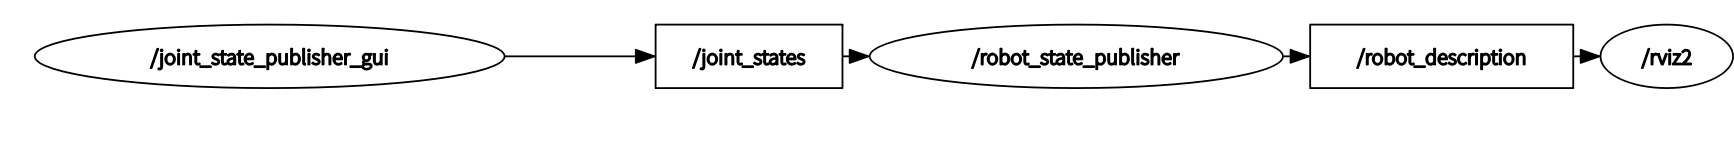

## 新建节点
```
cd chapt8/chapt8_ws/src
touch fishbot_description/fishbot_description/rotate_wheel.py
```
rotate_wheel.py如下
```py
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node


class RotateWheelNode(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info(f"node {name} init..")

def main(args=None):
    """
    ros2运行该节点的入口函数
    1. 导入库文件
    2. 初始化客户端库
    3. 新建节点
    4. spin循环节点
    5. 关闭客户端库
    """
    rclpy.init(args=args) # 初始化rclpy
    node = RotateWheelNode("rotate_fishbot_wheel")  # 新建一个节点
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy
```

配置下setup.py
```py
    entry_points={
        'console_scripts': [
            "rotate_wheel= fishbot_description.rotate_wheel:main"
        ],
    },
```    

编译运行
```
colcon build
source install/setup.bash
ros2 run fishbot_description rotate_wheel
```

## 创建发布者
创建发布者之前，首先要知道robot_state_pubsher所订阅的话题类型是什么
```
ros2 topic info /joint_states

Type: sensor_msgs/msg/JointState
Publisher count: 1
Subscription count: 1
```
接着
```
ros2 interfaces show sensor_msgs/msg/JointState

# This is a message that holds data to describe the state of a set of torque controlled joints.
#
# The state of each joint (revolute or prismatic) is defined by:
#  * the position of the joint (rad or m),
#  * the velocity of the joint (rad/s or m/s) and
#  * the effort that is applied in the joint (Nm or N).
#
# Each joint is uniquely identified by its name
# The header specifies the time at which the joint states were recorded. All the joint states
# in one message have to be recorded at the same time.
#
# This message consists of a multiple arrays, one for each part of the joint state.
# The goal is to make each of the fields optional. When e.g. your joints have no
# effort associated with them, you can leave the effort array empty.
#
# All arrays in this message should have the same size, or be empty.
# This is the only way to uniquely associate the joint name with the correct
# states.

std_msgs/Header header

string[] name
float64[] position
float64[] velocity
float64[] effort
```
知道了话题类型，我们就可以来创建发布者了  
rotate_wheel.py
```py
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
# 1.导入消息类型JointState
from sensor_msgs.msg import JointState

class RotateWheelNode(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info(f"node {name} init..")
        # 2.创建并初始化发布者成员属性pub_joint_states_
        self.pub_joint_states_ = self.create_publisher(JointState,"joint_states", 10) 
```

## 编写发布逻辑
**多线程定频发布Rate**

创建好发布者，我们想让话题按照某个固定的速度进行发布，可以采用ROS2中的定时神器Rate

为了能够一直循环使用rate，我们单独开一个线程用于发布joint_states话题数据，在ROS2程序中单独开线程进行话题发布的方法为：  

```py
import threading
from rclpy.node import Node

class RotateWheelNode(Node):
    def __init__(self):
        # 创建一个Rate和线程
        self.pub_rate = self.create_rate(5) #5Hz
        # 创建线程
        self.thread_ = threading.Thread(target=self._thread_pub)
        self.thread_.start()

    def _thread_pub(self):
        while rclpy.ok():
            #做一些操作，使用rate保证循环频率
            self.pub_rate.sleep()
```

**构造发布数据**

joint_states有一个头和四个数组需要赋值（可通过ros2 interface指令查询）
```
std_msgs/Header header #时间戳信息 和 frame_id
string[] name
float64[] position
float64[] velocity
float64[] effort
```
对应的含义为：
```
# 这是一个持有数据的信息，用于描述一组扭矩控制的关节的状态。
#
# 每个关节（渐进式或棱柱式）的状态由以下因素定义。
# #关节的位置（rad或m）。
# #关节的速度（弧度/秒或米/秒）和
# #在关节上施加的力（Nm或N）。
#
# 每个关节都由其名称来唯一标识
# 头部规定了记录关节状态的时间。所有的联合状态
# 必须是在同一时间记录的。
#
# 这个消息由多个数组组成，每个部分的联合状态都有一个数组。
# 目标是让每个字段都是可选的。例如，当你的关节没有
# 扭矩与它们相关，你可以让扭矩数组为空。
#
# 这个信息中的所有数组都应该有相同的大小，或者为空。
# 这是唯一能将关节名称与正确的
# 状态。
string[] name #关节名称数组
float64[] position #关节位置数组
float64[] velocity #关节速度数组
float64[] effort #扭矩数据
```

**name**  
关节的名称，要与urdf中的定义的关节名称相同，根据我们的URDF定义有
```py
self.joint_states.name = ['left_wheel_joint','right_wheel_joint']
```
**position**  
表示关节转动的角度值，因为关节类型为continuous,所以其值无上下限制，初始值赋值为0.0
```py
# 关节的位置
self.joint_states.position = [0.0,0.0]
```
我们采用速度控制机器人轮子转动，所以机器人的位置更新则可以通过下面式子计算得出

>某一段时间内轮子转动的角度 = （当前时刻-上一时刻）*两个时刻之间的轮子转速

```py
delta_time =  time.time()-last_update_time
# 更新位置
self.joint_states.position[0]  += delta_time*self.joint_states.velocity[0]
self.joint_states.position[1]  += delta_time*self.joint_states.velocity[1]
```
**velocity**  
因为我们采用速度进行控制，所以对外提供一个速度更改接口。
```py
def update_speed(self,speeds):
    self.joint_speeds = speeds
```   

rotate_wheel.py完整代码
```py
#!/usr/bin/env python3
import rclpy
from rclpy.node import Node
# 1.导入消息类型JointState
from sensor_msgs.msg import JointState

import threading
import time

class RotateWheelNode(Node):
    def __init__(self,name):
        super().__init__(name)
        self.get_logger().info(f"node {name} init..")
        # 创建并初始化发布者成员属性pub_joint_states_
        self.joint_states_publisher_ = self.create_publisher(JointState,"joint_states", 10) 
        # 初始化数据
        self._init_joint_states()
        self.pub_rate = self.create_rate(30)
        self.thread_ = threading.Thread(target=self._thread_pub)
        self.thread_.start()

    
    def _init_joint_states(self):
        # 初始左右轮子的速度
        self.joint_speeds = [0.0,0.0]
        self.joint_states = JointState()
        self.joint_states.header.stamp = self.get_clock().now().to_msg()
        self.joint_states.header.frame_id = ""
        # 关节名称
        self.joint_states.name = ['left_wheel_joint','right_wheel_joint']
        # 关节的位置
        self.joint_states.position = [0.0,0.0]
        # 关节速度
        self.joint_states.velocity = self.joint_speeds
        # 力 
        self.joint_states.effort = []

    def update_speed(self,speeds):
        self.joint_speeds = speeds

    def _thread_pub(self):
        last_update_time = time.time()
        while rclpy.ok():
            delta_time =  time.time()-last_update_time
            last_update_time = time.time()
            # 更新位置
            self.joint_states.position[0]  += delta_time*self.joint_states.velocity[0]
            self.joint_states.position[1]  += delta_time*self.joint_states.velocity[1]
            # 更新速度
            self.joint_states.velocity = self.joint_speeds
            # 更新 header
            self.joint_states.header.stamp = self.get_clock().now().to_msg()
            # 发布关节数据
            self.joint_states_publisher_.publish(self.joint_states)
            self.pub_rate.sleep()

def main(args=None):
    rclpy.init(args=args) # 初始化rclpy
    node = RotateWheelNode("rotate_fishbot_wheel")  # 新建一个节点
    node.update_speed([15.0,-15.0])
    rclpy.spin(node) # 保持节点运行，检测是否收到退出指令（Ctrl+C）
    rclpy.shutdown() # 关闭rclpy


## 编译测试

测试之前还需要修改下display_rviz2.launch.py文件，注释其joint_state_publisher节点
```py
# ld.add_action(joint_state_publisher_node)
ld.add_action(robot_state_publisher_node)
ld.add_action(rviz2_node)
```

编译程序
```
colcon build --packages-select fishbot_description
```

先运行rviz和robot_state_publisher
```
source install/setup.bash
ros2 launch fishbot_description display_rviz2.launch.py
```

新开终端，运行关节数据发布节点
```
cd chapt8/chapt8_ws/src
source install/setup.bash
ros2 run fishbot_description rotate_wheel
```

观察此时rviz界面，可以看到轮子疯狂转动

# 机器人仿真介绍
机器人仿真其实就是通过软件来模仿硬件的特性，用于验证机器人算法、架构等。

**为什么需要机器人仿真**

对于个人极客来说，直接动手比仿真要来的快和直接的多。单对于公司和非常复杂的项目来说，仿真就变得很重要了。

原因在于：

1. 仿真可以解决真机资源不足，真实的机器人一般价格都很贵，搭建起来也很耗费资源。

2. 仿真可以保证环境的一致和稳定。

3. 仿真场景可以更加灵活，在测试机器人算法时可以通过仿真软件快速更改仿真环境，验证算法

**仿真有哪些缺点**

现实世界中的环境非常复杂，光线、材质、电磁干扰等等，仿真平台无法做到100%的仿真。

**常用仿真平台**

相较于ROS，ROS2支持更多更专业的仿真平台，常用的有：
- ``Gazebo``
- ``WeBots``  
  Webots由Cyberbotics公司开发，是一个用于模拟机器人的开源和多平台桌面应用程序。  
  它提供了一个完整的开发环境来对机器人进行建模、编程和仿真。  
  Webots内核基于开源动力学引擎ODE和OpenGL，可以在Windows，Linux和macOS上运行，并且支持多种编程语言(C/C++，Python，Java，MATLAB)。
- ``Ignition``  
  继承于Gazebo的下一代仿真平台，Ignition Robotics基于开发库和云服务等丰富全面的工具箱，提供了一种全新的仿真方式，进一步简化仿真。  
  高度逼真的传感器可在接近真实的环境中快速迭代更新机器人物理设计。在安全上可测试控制策略，并在持续的集成化侧重中利用仿真的诸多优势。  
- ``Unity``  
  Unity Robotics软件包带有许多现成的接口，能让你轻松与ROS或ROS 2的交换信息。  
  你也能用URDF Importer直接从URDF文件中导入机器人配置，在Unity高质量的渲染管线与高精度的物理模拟加持下开始训练机器人。  
  Unity的Asset Store还售有大量现成的环境和道具，可用于补充机器人的训练环境、完善训练任务。  
  只需几键，你搭建的模拟就可以构建并部署到Windows 10、Mac OS或Linux等任意主流操作系统。  
  你甚至可以使用C#、Bolt可视化编程及Asset Store上的众多脚本和实用程序来根据自己的需求进一步定制模拟环境。

**我们用哪个仿真平台？**

鉴于从ROS和Gazebo中得到的大量经验，我们依然选择Gazebo作为本次进行仿真的主要平台

# 为机器人URDF模型添加物理参数
机器人仿真就是用软件来模拟硬件的特性，那么我们必须要告诉仿真平台机器人各个关节的物理属性。

所以这节需要将物理信息写入到urdf中，让机器人在gazebo中显示出来。

## **物理参数**

一般来说有``碰撞``和``内参``两个就够了，这里再加一个摩擦力配置  

碰撞描述是物体的用于碰撞检测的包围形状。内参用于描述物体的质量，惯性矩阵。link的摩擦力。

**碰撞检测**

在机器人仿真中，我们要对物体之前是否接触，是否发生碰撞做检测，常用的检测方法比如包围盒，判断两个物体的包围盒是否相交来快速判断物体是否发生碰撞。

在URDF中，我们可以可以在link标签下添加collison子标签来对物体的形状进行描述。

collision可以包含的子标签如下：
- origin，表示碰撞体的中心位姿
- geometry，用于表示用于碰撞检测的几何形状
- material，可选的，描述碰撞几何体的材料(这个设置可以在gazebo仿真时通过view选项看到碰撞包围体的形状)

In [ ]:
    <collision>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
      <material name="blue">
          <color rgba="0.1 0.1 1.0 0.5" /> 
      </material>
    </collision>

**旋转惯量**

旋转惯量矩阵是用于描述物体的惯性的，在做动力学仿真的时候，这些参数尤为重要。

在URDF中我们可以通过在link下添加inertial子标签，为link添加惯性参数的描述。

intertial标签包含的子标签如下：
- mass，描述link的质量
- inertia，描述link的旋转惯量（该标签有六个属性值ixx\ixy\ixz\iyy\iyz\izz）

In [ ]:
   <inertial>
      <mass value="0.2"/>
      <inertia ixx="0.0122666" ixy="0" ixz="0" iyy="0.0122666" iyz="0" izz="0.02"/>
    </inertial>


关于intertial的属性设置，不是随意设置的，常见的几何体我们可以通过公式进行计算。

**摩擦力和刚性系数**

在Fishbot的URDF中，前面的支撑轮主要起支撑作用，因为我们将其使用fixed标签固定到了base_link上，所以它无法转动。

该怎么办呢？我们可以要把这个轮子的摩擦力设置为0，让它直接在地上滑动即可。

其中mu1,mu2代表摩擦力，kp,kd代表刚性系数。

In [ ]:
  <gazebo reference="caster_link">
    <mu1 value="0.0"/>
    <mu2 value="0.0"/>
    <kp value="1000000.0" />
    <kd value="10.0" />
  </gazebo>


## 完整base_link如下
>注意：要将以下内容修改到urdf文件中，否则之后的Gazebo会报错（因为缺少物理参数导致 Gazebo 在构建模型的物理表示（与图结构相关）时出现问题）

In [ ]:
  <!-- base link -->
  <link name="base_link">
      <visual>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
      <material name="blue">
          <color rgba="0.1 0.1 1.0 0.5" /> 
      </material>
    </visual>
    <collision>
      <origin xyz="0 0 0.0" rpy="0 0 0"/>
      <geometry>
        <cylinder length="0.12" radius="0.10"/>
      </geometry>
      <material name="blue">
          <color rgba="0.1 0.1 1.0 0.5" /> 
      </material>
    </collision>
    <inertial>
      <mass value="0.2"/>
      <inertia ixx="0.0122666" ixy="0" ixz="0" iyy="0.0122666" iyz="0" izz="0.02"/>
    </inertial>
  </link>


# Gazebo加载URDF
gazebo是独立于ROS/ROS2之外的仿真软件，我们可以独立使用Gazebo。如果我们想要通过ROS2和Gazebo进行交互，需要通过gazebo_ros插件来进行。

## Gazebo插件
安装Gazebo插件
```
sudo apt install ros-humble-gazebo-ros
```
启动Gazebo并启动插件
```
gazebo --verbose -s libgazebo_ros_init.so -s libgazebo_ros_factory.so 
```
查看插件的节点
```
ros2 node list

/gazebo
```
查看这个节点对外提供的服务
```
ros2 service list

/delete_entity
/get_model_list
/spawn_entity
/gazebo/describe_parameters
/gazebo/get_parameter_types
/gazebo/get_parameters
/gazebo/list_parameters
/gazebo/set_parameters
/gazebo/set_parameters_atomically
```
除去和参数相关的几个服务，我们可以看到另外三个特殊服务：
- /spawn_entity，用于加载模型到gazebo中
- /get_model_list，用于获取模型列表
- /delete_entity，用于删除gazbeo中已经加载的模型

我们想要让gazebo显示出我们配置好的fishbot使用/spawn_entity来加载即可。

先查看服务的接口类型
```
ros2 service type /spawn_entity

gazebo_msgs/srv/SpawnEntity
```
然后
```
ros2 interface show gazebo_msgs/srv/SpawnEntity

string name                       # Name of the entity to be spawned (optional).
string xml                        # Entity XML description as a string, either URDF or SDF.
string robot_namespace            # Spawn robot and all ROS interfaces under this namespace
geometry_msgs/Pose initial_pose   # Initial entity pose.
string reference_frame            # initial_pose is defined relative to the frame of this entity.
                                  # If left empty or "world" or "map", then gazebo world frame is
                                  # used.
                                  # If non-existent entity is specified, an error is returned
                                  # and the entity is not spawned.
---
bool success                      # Return true if spawned successfully.
string status_message             # Comments if available.
```
可以看到服务的请求内容包括：

- ``string name`` ，需要加载的实体的名称 (可选的)。
- ``string xml`` ，实体的XML描述字符串, URDF或者SDF。
- ``string robot_namespace`` ，产生的机器人和所有的ROS接口的命名空间，多机器人仿真的时候很有用。
- ``geometry_msgs/Pose initial_pose`` ，机器人的初始化位置
- ``string reference_frame`` ，初始姿态是相对于该实体的frame定义的。如果保持"empty"或"world"或“map”，则使用 gazebo的world作为frame。如果指定了不存在的实体，则会返回错误

## 调用服务加载机器人
在rqt工具集里有一个叫服务请求工具。

命令行输入rqt，在插件选项中选择Services->Service Caller,然后再下拉框选择/spawn_entity服务。

接着我们把我们的FishBot的URDF模型复制粘贴，放到xml中（注意要把原来的''删掉），然后点击小电话Call图标。

此时界面出现一个白色机器人，按住Shift加鼠标左键，拖动。

**在不同位置加载多个机器人**

修改rqt中的参数，增加一个命名空间，然后修改一个位置，让第二个机器人和第一个相距1m的地方生产，然后点击Call。

![image.png](http://fishros.com/d2lros2/humble/chapt9/get_started/3.%E5%9C%A8Gazebo%E5%8A%A0%E8%BD%BD%E6%9C%BA%E5%99%A8%E4%BA%BA%E6%A8%A1%E5%9E%8B/imgs/image-20220405234507958.png)

此时拖动Gazebo观察一下，发现多出了一个机器人，距离刚好是在X轴（红色）1米（一个小格子一米）处。

**查询和删除机器人**

用rqt工具，我们再对另外两个服务接口进行请求。

![image.png](http://fishros.com/d2lros2/humble/chapt9/get_started/3.%E5%9C%A8Gazebo%E5%8A%A0%E8%BD%BD%E6%9C%BA%E5%99%A8%E4%BA%BA%E6%A8%A1%E5%9E%8B/imgs/image-20220405234948237.png)

![image.png](http://fishros.com/d2lros2/humble/chapt9/get_started/3.%E5%9C%A8Gazebo%E5%8A%A0%E8%BD%BD%E6%9C%BA%E5%99%A8%E4%BA%BA%E6%A8%A1%E5%9E%8B/imgs/image-20220405235058954.png)

查到了三个模型，一个大地，一个fishbot，一个fishbot_0。

我们接着尝试把fishbot_0删掉，选择删除实体，输入fishbot_0的名字，点击小电话Call按钮，通知工厂回收我们的fishbot_0。

## 将启动gazebo和生产fishbot写成launch文件
在src/fishbot_description/launch中添加一个gazebo.launch.py文件

In [ ]:
import os
from launch import LaunchDescription
from launch.actions import ExecuteProcess
from launch_ros.actions import Node
from launch_ros.substitutions import FindPackageShare


def generate_launch_description():
    robot_name_in_model = 'fishbot'
    package_name = 'fishbot_description'
    urdf_name = "fishbot_gazebo.urdf"

    ld = LaunchDescription()
    pkg_share = FindPackageShare(package=package_name).find(package_name) 
    urdf_model_path = os.path.join(pkg_share, f'urdf/{urdf_name}')

    # Start Gazebo server
    start_gazebo_cmd =  ExecuteProcess(
        cmd=['gazebo', '--verbose','-s', 'libgazebo_ros_init.so', '-s', 'libgazebo_ros_factory.so'],
        output='screen')

    # Launch the robot
    spawn_entity_cmd = Node(
        package='gazebo_ros', 
        executable='spawn_entity.py',
        arguments=['-entity', robot_name_in_model,  '-file', urdf_model_path ], output='screen')

    ld.add_action(start_gazebo_cmd)
    ld.add_action(spawn_entity_cmd)


    return ld

编译运行
```
colcon build --packages-select fishbot_description
source install/setup.bash
ros2 launch fishbot_description gazebo.launch.py
```

# Gazebo仿真插件之两轮差速
本节通过配置两轮差速控制插件，让我们的机器人动起来.

## Gazebo插件介绍
gazebo的插件按照用途大致可以分为两种：

- 用于控制的插件，通过插件可以控制机器人关节运动，可以进行位置、速度、力的控制。

- 用于数据采集的插件，比如IMU传感器用于采集机器人的惯性，激光雷达用于采集机器人周围的点云信息。

当然上面两类插件功能也可以写到一个插件里，两轮差速插件就是一个二合一加强版。

## 两轮差速插件介绍
两轮差速插件用于控制机器人轮子关节的位置变化，同时该插件还会获取轮子的位置以及速度的信息的反馈，根据反馈的位置信息结合运动学模型即可计算出当前机器人的位姿（里程计）。

该插件的名称为：``gazebo_ros_diff_drive``

两轮差速控制器可以将轮子的目标转速发送给Gazebo，并从Gazebo获取到实际的速度和位置。

>注意：发送给Gazebo是目标速度，反馈回来的是实际速度。目标!=实际，比如轮子卡住了，无论你发什么目标速度，实际速度都是0。

![image.png](image\gazebo_ros_diff_drive.png)

上图是对gazebo_ros_diff_drive的输入和输出信息的总结，可以很直观的看到该插件主要输入控制指令，主要输出里程计信息。

**输入参数**

|配置项|含义|
|:---:|:---:|
|ros|ros相关配置，包含命名空间和话题重映射等|
|update_rate|数据更新速率|
|left_joint|左轮关节名称|
|right_joint|右轮关节名称|
|wheel_separation|左右轮子的间距|
|wheel_diameter|轮子的直径|
|max_wheel_torque|轮子最大的力矩|
|max_wheel_acceleration|轮子最大的加速度|
|publish_odom|是否发布里程计|
|publish_odom_tf|是否发布里程计的tf开关|
|publish_wheel_tf|是否发布轮子的tf数据开关|
|odometry_frame|里程计的framed ID，最终体现在话题和TF上|
|robot_base_frame|机器人的基础frame的ID|

两轮差速控制器默认通过订阅话题``cmd_vel``来获取目标线速度和角速度。该话题的类型为：``geometry_msgs/msg/Twist``
```
ros2 interface show geometry_msgs/msg/Twist
```
用proto再看一下包含的基本数据类型有哪些
```
ros2 interface proto geometry_msgs/msg/Twist
```

**输出参数**

里程计信息默认的输出话题为odom，其消息类型为：nav_msgs/msg/Odometry

同上使用CLI看一下其消息的组成结构

## 在URDF中配置两轮差速模型
因为是给Gazebo的插件，所以在URDF中，我们需要使用gazebo进行配置，因为是要给gazebo配置插件，所有要在gazebo标签下添加plugin子插件。

In [ ]:
  <gazebo>
    <plugin name='diff_drive' filename='libgazebo_ros_diff_drive.so'>
          <ros>
            <namespace>/</namespace>
            <remapping>cmd_vel:=cmd_vel</remapping>
            <remapping>odom:=odom</remapping>
          </ros>
          <update_rate>30</update_rate>
          <!-- wheels -->
          <left_joint>left_wheel_joint</left_joint>
          <right_joint>right_wheel_joint</right_joint>
          <!-- kinematics -->
          <wheel_separation>0.2</wheel_separation>
          <wheel_diameter>0.065</wheel_diameter>
          <!-- limits -->
          <max_wheel_torque>20</max_wheel_torque>
          <max_wheel_acceleration>1.0</max_wheel_acceleration>
          <!-- output -->
          <publish_odom>true</publish_odom>
          <publish_odom_tf>true</publish_odom_tf>
          <publish_wheel_tf>true</publish_wheel_tf>
          <odometry_frame>odom</odometry_frame>
          <robot_base_frame>base_footprint</robot_base_frame>
      </plugin>

## 两轮差速插件测试  
```
colcon build
source install/setup.bash
ros2 launch fishbot_description gazebo.launch.py
```
接着你可以使用CLI工具看一下系统有哪些节点在运行
```
ros2 node list
ros2 topic list
```
此时你已经看到了我们插件订阅的的/cmd_vel和发布的/odom了。

**使用键盘控制机器人**  

你需要一个键盘控制工具，可以用下面的指令安装
```
sudo apt install ros-humble-teleop-twist-keyboard
```
这个功能包下有一个节点，这个节点会监听键盘的按键事件，然后发布cmd_vel话题，该话题被gazebo的两轮差速插件所订阅。所以我们就可以通过这个节点来控制fishbot。
```
ros2 run teleop_twist_keyboard teleop_twist_keyboard
```
>如果你想让这个节点不是发布cmd_vel话题，而是别的，可以采用ROS2的话题重映射功能。  
ros2 run teleop_twist_keyboard teleop_twist_keyboard --ros-args --remap cmd_vel:=cmd_vel1

接着尝试使用来控制机器人运动
```
   U    I    O
   J    K    L
   M    <    >
```

点一下I，你就能看到fishbot在Gazebo中飞速的移动。接着打开终端，打印一下odom话题和tf话题，移动机器人观察数据变化。

**使用rqt显示速度数据**  

选择Plugin->Visualization->Plot

在上方Topic输入``/cmd_vel/linear/x``，再输入``/cmd_vel/angular/z``，然后用键盘控制机器人移动。

![image.png](http://fishros.com/d2lros2/humble/chapt9/get_started/4.Gazebo%E4%BB%BF%E7%9C%9F%E6%8F%92%E4%BB%B6%E4%B9%8B%E4%B8%A4%E8%BD%AE%E5%B7%AE%E9%80%9F/imgs/image-20220408131855683.png)

cmd_vel中的速度代表目标速度，接着我们显示一下当前速度（在odom.twist中）

![](http://fishros.com/d2lros2/humble/chapt9/get_started/4.Gazebo%E4%BB%BF%E7%9C%9F%E6%8F%92%E4%BB%B6%E4%B9%8B%E4%B8%A4%E8%BD%AE%E5%B7%AE%E9%80%9F/imgs/image-20220408141925261.png)



**在RVIZ2中显示Fishbot及其轨迹**  

修改FixedFrame为odom  
添加插件，Add->Odometry->OK  
选择话题，Odometry->Topic->选/odom  
去除协方差显示，Odometry->Covariance>取消勾选  
键盘控制节点，点个U，原地转圈圈  

![](http://fishros.com/d2lros2/humble/chapt9/get_started/4.Gazebo%E4%BB%BF%E7%9C%9F%E6%8F%92%E4%BB%B6%E4%B9%8B%E4%B8%A4%E8%BD%AE%E5%B7%AE%E9%80%9F/imgs/image-20220408142436034.png)

**在RVIZ2中显示机器人模型**  

虽然机器人的轨迹已经在RVIZ中显示出来了，但是并没有机器人的模型，也看不到轮子的转动。

要发布机器人模型我们所使用的节点是robot_state_publisher,所以我们在gazebo.launch.py中加入这个节点，同时再加上rviz2的启动节点，最终的gazebo.launch.py内容如下：
```py
import os
from launch import LaunchDescription
from launch.actions import ExecuteProcess
from launch_ros.actions import Node
from launch_ros.substitutions import FindPackageShare


def generate_launch_description():
    robot_name_in_model = 'fishbot'
    package_name = 'fishbot_description'
    urdf_name = "fishbot_gazebo.urdf"

    ld = LaunchDescription()
    pkg_share = FindPackageShare(package=package_name).find(package_name) 
    urdf_model_path = os.path.join(pkg_share, f'urdf/{urdf_name}')

    # Start Gazebo server
    start_gazebo_cmd =  ExecuteProcess(
        cmd=['gazebo', '--verbose','-s', 'libgazebo_ros_init.so', '-s', 'libgazebo_ros_factory.so', gazebo_world_path],
        output='screen')
        
    # Launch the robot
    spawn_entity_cmd = Node(
        package='gazebo_ros', 
        executable='spawn_entity.py',
        arguments=['-entity', robot_name_in_model,  '-file', urdf_model_path ], output='screen')
    
    # Start Robot State publisher
    start_robot_state_publisher_cmd = Node(
        package='robot_state_publisher',
        executable='robot_state_publisher',
        arguments=[urdf_model_path]
    )

    # Launch RViz
    start_rviz_cmd = Node(
        package='rviz2',
        executable='rviz2',
        name='rviz2',
        output='screen',
        # arguments=['-d', default_rviz_config_path]
        )

    ld.add_action(start_gazebo_cmd)
    ld.add_action(spawn_entity_cmd)
    ld.add_action(start_robot_state_publisher_cmd)
    ld.add_action(start_rviz_cmd)


    return ld
```

编译启动
```
colcon build
ros2 launch fishbot_description gazebo.launch.py
```
然后继续启动键盘控制，现在你可以在rviz2中看到机器人模型。

# Gazebo仿真插件之IMU

仿真的IMU也是对应一个后缀为.so的动态链接库，使用下面的指令可以查看所有的动态链接库：
```
ls /opt/ros/humble/lib/libgazebo_ros*
```

IMU对应的消息类型为sensor_msgs/msg/Imu
```
ros2 interface show sensor_msgs/msg/Imu

## urdf

有了上节的经验，我们可以很轻松的添加IMU传感器，但是还有一个需要注意的地方，为了更真实的模拟IMU传感器，我们需要给我们的仿真IMU传感器加点高斯噪声.

高斯噪声只需要指定平均值和标准差两个参数即可，不过因为IMU传感器的特殊性，我们还需要给模型添加两个偏差参数，分别是``平均值偏差``和``标准差偏差``。

MU对应的插件库libgazebo_ros_imu_sensor.so

In [ ]:
    <gazebo reference="imu_link">
      <sensor name="imu_sensor" type="imu">
      <plugin filename="libgazebo_ros_imu_sensor.so" name="imu_plugin">
          <ros>
            <namespace>/</namespace>
            <remapping>~/out:=imu</remapping>
          </ros>
          <initial_orientation_as_reference>false</initial_orientation_as_reference>
        </plugin>
        <always_on>true</always_on>
        <update_rate>100</update_rate>
        <visualize>true</visualize>
        <imu>
          <angular_velocity>
            <x>
              <noise type="gaussian">
                <mean>0.0</mean>
                <stddev>2e-4</stddev>
                <bias_mean>0.0000075</bias_mean>
                <bias_stddev>0.0000008</bias_stddev>
              </noise>
            </x>
            <y>
              <noise type="gaussian">
                <mean>0.0</mean>
                <stddev>2e-4</stddev>
                <bias_mean>0.0000075</bias_mean>
                <bias_stddev>0.0000008</bias_stddev>
              </noise>
            </y>
            <z>
              <noise type="gaussian">
                <mean>0.0</mean>
                <stddev>2e-4</stddev>
                <bias_mean>0.0000075</bias_mean>
                <bias_stddev>0.0000008</bias_stddev>
              </noise>
            </z>
          </angular_velocity>
          <linear_acceleration>
            <x>
              <noise type="gaussian">
                <mean>0.0</mean>
                <stddev>1.7e-2</stddev>
                <bias_mean>0.1</bias_mean>
                <bias_stddev>0.001</bias_stddev>
              </noise>
            </x>
            <y>
              <noise type="gaussian">
                <mean>0.0</mean>
                <stddev>1.7e-2</stddev>
                <bias_mean>0.1</bias_mean>
                <bias_stddev>0.001</bias_stddev>
              </noise>
            </y>
            <z>
              <noise type="gaussian">
                <mean>0.0</mean>
                <stddev>1.7e-2</stddev>
                <bias_mean>0.1</bias_mean>
                <bias_stddev>0.001</bias_stddev>
              </noise>
            </z>
          </linear_acceleration>
        </imu>
      </sensor>
    </gazebo>


## 编译测试
```
colcon build

ros2 launch fishbot_description gazebo.launch.py
```

## 解决gazebo失败方案

修改 URDF 文件，添加 Gazebo ROS 控制插件  

在你的 URDF 文件末尾（在 </robot> 标签之前）添加以下内容：

In [ ]:
  <!-- Gazebo ROS Control -->
  <gazebo>
    <plugin name="gazebo_ros_control" filename="libgazebo_ros_control.so">
      <robotNamespace>/</robotNamespace>
      <robotSimType>gazebo_ros_control/DefaultRobotHWSim</robotSimType>
    </plugin>
  </gazebo>

  <!-- 为左右轮添加传输 -->
  <gazebo reference="left_wheel_link">
    <mu1>0.2</mu1>
    <mu2>0.2</mu2>
    <kp>1000000.0</kp>
    <kd>1.0</kd>
    <minDepth>0.001</minDepth>
    <maxVel>1.0</maxVel>
  </gazebo>

  <gazebo reference="right_wheel_link">
    <mu1>0.2</mu1>
    <mu2>0.2</mu2>
    <kp>1000000.0</kp>
    <kd>1.0</kd>
    <minDepth>0.001</minDepth>
    <maxVel>1.0</maxVel>
  </gazebo>

修改launch启动文件，添加延迟和更好的启动方式

In [ ]:
import os
from launch import LaunchDescription
from launch.actions import ExecuteProcess, TimerAction
from launch_ros.actions import Node
from launch_ros.substitutions import FindPackageShare
from ament_index_python.packages import get_package_share_directory


def generate_launch_description():
    robot_name_in_model = 'fishbot'
    package_name = 'fishbot_description'
    urdf_name = "fishbot_base.urdf"

    ld = LaunchDescription()
    pkg_share = FindPackageShare(package=package_name).find(package_name) 
    urdf_model_path = os.path.join(pkg_share, f'urdf/{urdf_name}')

    # 启动 Gazebo 服务器（使用更好的参数）
    start_gazebo_cmd = ExecuteProcess(
        cmd=['gazebo', '--verbose', '-s', 'libgazebo_ros_factory.so', '-s', 'libgazebo_ros_init.so', 'worlds/empty.world'],
        output='screen'
    )

    # 使用 TimerAction 延迟生成实体，确保 Gazebo 完全启动
    spawn_entity_cmd = TimerAction(
        period=5.0,  # 等待 5 秒
        actions=[
            Node(
                package='gazebo_ros',
                executable='spawn_entity.py',
                arguments=[
                    '-entity', robot_name_in_model,
                    '-file', urdf_model_path,
                    '-x', '0.0',
                    '-y', '0.0', 
                    '-z', '0.1'
                ],
                output='screen'
            )
        ]
    )

    ld.add_action(start_gazebo_cmd)
    ld.add_action(spawn_entity_cmd)

    return ld

# Gazebo仿真插件之激光雷达

因为激光雷达是属于射线类传感器，该类传感在在Gazebo插件中都被封装成了一个动态库libgazebo_ros_ray_sensor.so。

接着我们来看看LiDAR的话题消息接口sensor_msgs/msg/LaserScan。
```
ros2 interface show  sensor_msgs/msg/LaserScan

## urdf

In [ ]:
  <gazebo reference="laser_link">
      <sensor name="laser_sensor" type="ray">
      <always_on>true</always_on>
      <visualize>true</visualize>
      <update_rate>5</update_rate>
      <pose>0 0 0.075 0 0 0</pose>
      <ray>
          <scan>
            <horizontal>
              <samples>360</samples>
              <resolution>1.000000</resolution>
              <min_angle>0.000000</min_angle>
              <max_angle>6.280000</max_angle>
            </horizontal>
          </scan>
          <range>
            <min>0.120000</min>
            <max>3.5</max>
            <resolution>0.015000</resolution>
          </range>
          <noise>
            <type>gaussian</type>
            <mean>0.0</mean>
            <stddev>0.01</stddev>
          </noise>
      </ray>

      <plugin name="laserscan" filename="libgazebo_ros_ray_sensor.so">
        <ros>
          <remapping>~/out:=scan</remapping>
        </ros>
        <output_type>sensor_msgs/LaserScan</output_type>
        <frame_name>laser_link</frame_name>
      </plugin>
      </sensor>
    </gazebo>


可以看到:

- 雷达也可以设置更新频率update_rate，这里设置为5

- 雷达可以设置分辨率，设置为1，采样数量360个，最终生成的点云数量就是360

- 雷达也有噪声，模型为gaussian

- 雷达有扫描范围range，这里配置成0.12-3.5，0.015分辨率

- 雷达的pose就是雷达的joint中位置的设置值

## 编译测试
```
colcon build
source install/setup.bash
ros2 launch fishbot_description gazebo.launch.py

```
ros2 topic list
ros2 topic info /scan
ros2 topic echo /scan
```